In [96]:
import pandas as pd
import os
path = "C:/Users/yulya/OneDrive/Рабочий стол/formula1-analysis/data/raw_data"
results = pd.read_csv(os.path.join(path, "results.csv"))
races = pd.read_csv(os.path.join(path, "races.csv"))
circuits = pd.read_csv(os.path.join(path, "circuits.csv"))
constructors = pd.read_csv(os.path.join(path, "constructors.csv"))

In [34]:
print(os.listdir(path))

['circuits.csv', 'constructors.csv', 'constructor_results.csv', 'constructor_standings.csv', 'drivers.csv', 'driver_standings.csv', 'lap_times.csv', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv']


In [35]:
df = results.merge(races, on="raceId")
df = df.merge(circuits, on="circuitId")
df = df.merge(constructors, on="constructorId")

In [36]:
print(df.columns)

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time_x',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'name_x',
       'date', 'time_y', 'url_x', 'fp1_date', 'fp1_time', 'fp2_date',
       'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time',
       'sprint_date', 'sprint_time', 'circuitRef', 'name_y', 'location',
       'country', 'lat', 'lng', 'alt', 'url_y', 'constructorRef', 'name',
       'nationality', 'url'],
      dtype='object')


In [37]:
df = df[[
    "raceId",
    "driverId",
    "year",
    "name_x",
    "name_y",
    "grid",
    "positionOrder",
    "name"
]]

In [38]:
df.columns = [
    "raceId",
    "driverId",
    "year",
    "race",
    "circuit",
    "grid",
    "position",
    "constructor",
]

In [39]:
df["overtake"] = df["grid"] - df["position"] #обгоны

In [40]:
def get_circuit_type(circuit):
    street = ["monaco", "baku", "singapore"]
    if any(s in circuit.lower() for s in street):
        return "street"
    return "permanent"

df["circuit_type"] = df["circuit"].apply(get_circuit_type)

In [51]:
df = df[df["grid"] > 0]
df = df.dropna()
df = df[df["year"] >= 2018]

In [52]:
df.to_csv("clean_data.csv", index=False)

In [53]:
df.describe()

,raceId,driverId,year,grid,position,overtake
count,2909.000000,2909.000000,2909.000000,2909.000000,2909.000000,2909.000000
mean,1065.899278,695.085596,2021.092472,10.305947,10.401856,-0.095909
std,45.870847,309.137542,2.034953,5.674447,5.770700,5.014636
min,989.000000,1.000000,2018.000000,1.000000,1.000000,-19.000000
25%,1025.000000,815.000000,2019.000000,5.000000,5.000000,-2.000000
50%,1066.000000,832.000000,2021.000000,10.000000,10.000000,0.000000
75%,1107.000000,846.000000,2023.000000,15.000000,15.000000,3.000000
max,1144.000000,862.000000,2024.000000,20.000000,20.000000,18.000000


In [54]:
df["grid"].corr(df["position"])

np.float64(0.616171859847556)

In [88]:
#победыпостартовымпозициям
winners = df[df["position"] == 1]

wins_by_grid = winners["grid"].value_counts().sort_index()

<Axes: xlabel='grid'>

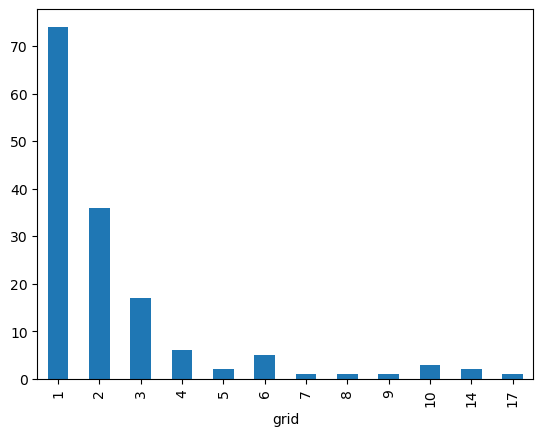

In [57]:
wins_by_grid.plot(kind="bar")

In [89]:
#победыкоманд
team_wins = winners["constructor"].value_counts().head(10)

In [82]:
wins_by_constructor = df[df["position"] == 1]["constructor"].value_counts()
print(wins_by_constructor)

constructor
Red Bull          67
Mercedes          53
Ferrari           19
McLaren            7
AlphaTauri         1
Racing Point       1
Alpine F1 Team     1
Name: count, dtype: int64


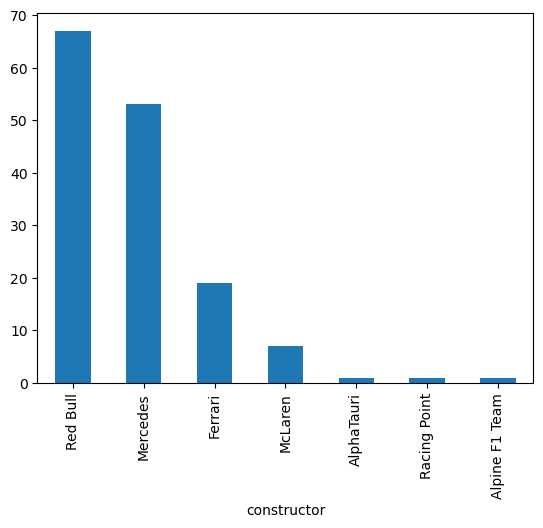

In [97]:
team_wins.plot(kind="bar")
plt.savefig("visualizations/team_wins.png", dpi=300, bbox_inches='tight')

In [95]:
#самыйбольшойподъемпопозициям
df.sort_values(by="overtake", ascending=False).head(10)

,raceId,driverId,year,race,circuit,grid,position,constructor,overtake,circuit_type
25241,1066,830,2021,Russian Grand Prix,Sochi Autodrom,20,2,Red Bull,18,permanent
24401,1020,20,2019,German Grand Prix,Hockenheimring,20,2,Ferrari,18,permanent
24583,1029,832,2019,Brazilian Grand Prix,Autódromo José Carlos Pace,20,3,McLaren,17,permanent
26741,1144,844,2024,Abu Dhabi Grand Prix,Yas Marina Circuit,19,3,Ferrari,16,permanent
24118,1006,830,2018,United States Grand Prix,Circuit of the Americas,18,2,Red Bull,16,permanent
24604,1030,822,2019,Abu Dhabi Grand Prix,Yas Marina Circuit,20,4,Mercedes,16,permanent
26679,1141,830,2024,São Paulo Grand Prix,Autódromo José Carlos Pace,17,1,Red Bull,16,permanent
25222,1065,822,2021,Italian Grand Prix,Autodromo Nazionale di Monza,19,3,Mercedes,16,permanent
24020,1001,822,2018,Belgian Grand Prix,Circuit de Spa-Francorchamps,19,4,Mercedes,15,permanent
25624,1085,832,2022,French Grand Prix,Circuit Paul Ricard,19,5,Ferrari,14,permanent


In [90]:
#среднийподъемпопозициям
df["overtake"].mean()

np.float64(-0.09590924716397388)

In [91]:
#среднийподъемпопозициямвзависимостиоттрассы
df.groupby("circuit_type")["overtake"].mean()

circuit_type
permanent   -0.090807
street      -0.154506
Name: overtake, dtype: float64

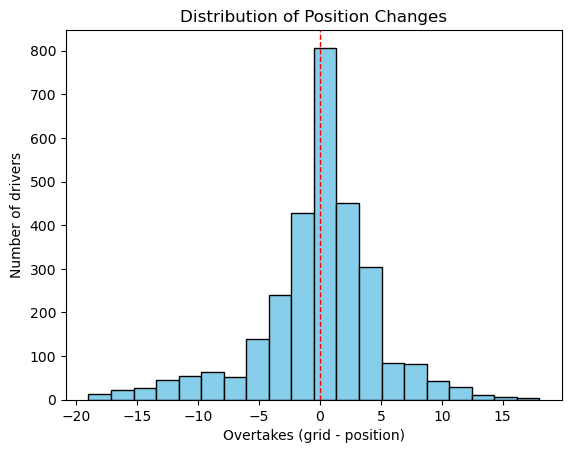

In [66]:
import matplotlib.pyplot as plt

plt.hist(df["overtake"], bins=20, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
plt.xlabel("Overtakes (grid - position)")
plt.ylabel("Number of drivers")
plt.title("Distribution of Position Changes")
plt.show()

In [68]:
#линейнаярегрессия
from sklearn.linear_model import LinearRegression
import pandas as pd

X = df[["grid", "overtake"]]
y = df["position"]

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
print("Коэффициенты:", model.coef_)

Коэффициенты: [ 1. -1.]


In [71]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)

print("R2:", r2_score(y, y_pred))

R2: 1.0


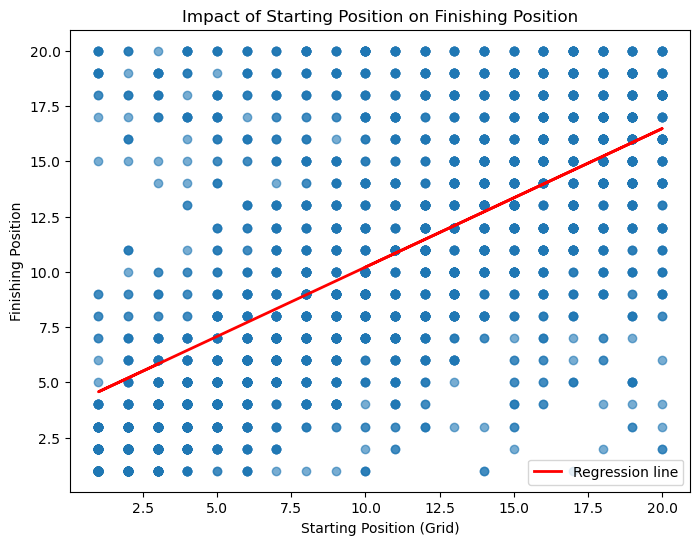

In [87]:
import os

if not os.path.exists("visualizations"):
    os.makedirs("visualizations")
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(df["grid"], df["position"], alpha=0.6)

#Простаялинейнаярегрессияпоgrid
m, b = np.polyfit(df["grid"], df["position"], 1)
plt.plot(df["grid"], m*df["grid"] + b, color='red', linewidth=2, label='Regression line')

plt.xlabel("Starting Position (Grid)")
plt.ylabel("Finishing Position")
plt.title("Impact of Starting Position on Finishing Position")
plt.legend()
plt.show()

In [75]:
df_scatter = df[["grid", "position"]]
df_scatter.to_csv("visualizations/scatter.csv", index=False)

In [76]:
winners = df[df["position"] == 1]
wins_by_grid = winners["grid"].value_counts().sort_index()
wins_by_grid = wins_by_grid.reset_index()
wins_by_grid.columns = ["grid", "wins"]
wins_by_grid.to_csv("visualizations/wins_by_grid.csv", index=False)

In [77]:
overtakes_by_type = df.groupby("circuit_type")["overtake"].mean().reset_index()
overtakes_by_type.to_csv("visualizations/overtakes_by_circuit.csv", index=False)

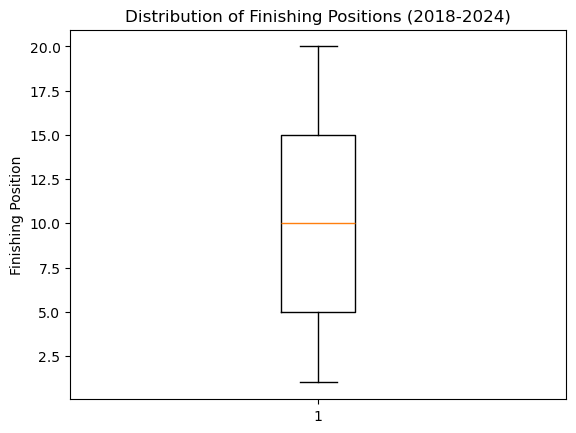

In [98]:
import matplotlib.pyplot as plt

plt.boxplot(df["position"])
plt.ylabel("Finishing Position")
plt.title("Distribution of Finishing Positions (2018-2024)")
plt.savefig("visualizations/boxplot_positions.png", dpi=300, bbox_inches='tight')
plt.show()

In [85]:
#доляпобедпостартовойпозиции
total_wins = df[df["position"] == 1].shape[0]
grid_wins = df[df["position"] == 1]["grid"].value_counts()
grid_wins_percentage = grid_wins / total_wins * 100
print(grid_wins_percentage)

grid
1     49.664430
2     24.161074
3     11.409396
4      4.026846
6      3.355705
10     2.013423
14     1.342282
5      1.342282
8      0.671141
7      0.671141
9      0.671141
17     0.671141
Name: count, dtype: float64


In [94]:
#измененияколичествапобедвпроцентахпосравнениюспредыдущимгодом
wins_by_year = df[df["position"] == 1].groupby(["year","constructor"]).size().unstack(fill_value=0)
pct_change = wins_by_year.pct_change().fillna(0) * 100
print(pct_change)

constructor  AlphaTauri  Alpine F1 Team  Ferrari  McLaren    Mercedes  \
year                                                                    
2018                0.0             0.0      0.0      0.0    0.000000   
2019                0.0             0.0    -50.0      0.0   36.363636   
2020                inf             0.0   -100.0      0.0  -13.333333   
2021             -100.0             inf      0.0      inf  -30.769231   
2022                0.0          -100.0      inf   -100.0  -88.888889   
2023                0.0             0.0    -75.0      0.0 -100.000000   
2024                0.0             0.0    400.0      inf         inf   

constructor  Racing Point    Red Bull  
year                                   
2018                  0.0    0.000000  
2019                  0.0  -25.000000  
2020                  inf  -33.333333  
2021               -100.0  450.000000  
2022                  0.0   54.545455  
2023                  0.0   23.529412  
2024                  